# Ximenez Cluster

In [420]:
import pandas as pd

In [556]:
lang = 'quc'
# lang = 'spa'

In [557]:
OHCO = ['folio','side','para','lb']
LINE = pd.read_csv(f"ximenez-{lang}-LINE.csv", sep='|').set_index(OHCO)

In [558]:
LINE

lb_n                                             lb_str  \
folio side para lb                                                            
1     1    1    1    1.0           <hi rend="very-large">ARE V XE OHER</hi>   
                2    2.0                              Ꜩih varal Quiche vbi.   
           2    3    3.0  <hi rend="large">V</hi>aral xchicaꜩibah vi xch...   
                4    4.0                   tiquiba vi oher ꜩih, vticaribal,   
                5    5.0                        vxenabal puch ronohel xban,   
...                  ...                                                ...   
56    2    97   32  32.0  qoheic <rs ana="TINAMIT_K'ICHE'">quicheri</rs>...   
                33  33.0  chi ilbalre, <rs ana="POPOL_WUJ">qonabe oher</...   
                34  34.0                     mal ahauab zachinac chic. xere   
                35  35.0  curi mixuꜩinic chiconohel <rs ana="TINAMIT_K'I...   
                36  36.0  che</rs> <rs ana="SANTA_CRUZ"><choice><abbr ty...   

                                         lb_str_plain  
folio side para lb                                     
1     1    1    1                       ARE V XE OHER  
                2              Tzih varal Quiche vbi.  
           2    3       Varal xchicatzibah vi xchica–  
                4   tiquiba vi oher tzih, vticaribal,  
                5         vxenabal puch ronohel xban,  
...                                               ...  
56    2    97   32       qoheic quicheri rumal mahabi  
                33       chi ilbalre, qonabe oher cu–  
                34     mal ahauab zachinac chic. xere  
                35    curi mixutzinic chiconohel qui–  
                36            che Sta.Santa Cruz vbi.  

[5249 rows x 3 columns]

# Gather

## Paragraphs

In [559]:
PARA = LINE.groupby(['para']).lb_str_plain.apply(lambda x: ' '.join(map(str,x))).to_frame('para_str')

In [560]:
PARA

,para_str
para,
1,ARE V XE OHER Tzih varal Quiche vbi.
2,Varal xchicatzibah vi xchica– tiquiba vi oher ...
3,"ARE V TzIHOXIC VAE Cacatzinin oc, caca chamam ..."
4,Vae cute nabe tzih nabe vch– an. mahabi oq' hu...
5,Ta xpe cut vtzih varal xul cuq ri tepeu gucuma...
...,...
93,Arecut nim ha ri chuvach ni– haibab are vbinaa...
94,Are chicut rech ahau qui che va vmam vcahau Ma...
95,Arecut ahauab ri chuvach ahau quiche are vleel...


In [561]:
PARA.para_str = PARA.para_str.str.replace(r"– ", "")
PARA['para_str_norm'] = PARA.para_str.str.lower().str.replace(r"[,.:;?\"']", "", regex=True)
PARA['len'] = PARA.para_str_norm.str.len()

In [562]:
PARA['g1'] = (PARA.index // 10) + 1
PARA['g2'] = (PARA.index % 10 ) + 1
PARA = PARA.reset_index().set_index(['g1','g2'])

In [563]:
PARA.head(10)

para                                           para_str  \
g1 g2                                                            
1  2      1               ARE V XE OHER Tzih varal Quiche vbi.   
   3      2  Varal xchicatzibah vi xchicatiquiba vi oher tz...   
   4      3  ARE V TzIHOXIC VAE Cacatzinin oc, caca chamam ...   
   5      4  Vae cute nabe tzih nabe vchan. mahabi oq' hun ...   
   6      5  Ta xpe cut vtzih varal xul cuq ri tepeu gucuma...   
   7      6  Ta xquinohih chic vchicopil huyub chahal re qu...   
   8      7  Ta xevqhax chicut ri queh tziquin rumal tzacol...   
   9      8  Xeqha qu ri huracan ruq tepeu gucumatz ta xqui...   
   10     9  Catecut qui quizic chic qui mayxic qui cutuxic...   
2  1     10  Are cut xa hubic zac na tanoh vvachvleu mahabi...   

                                           para_str_norm   len  
g1 g2                                                           
1  2                 are v xe oher tzih varal quiche vbi    35  
   3   varal xchicatzibah vi xchicatiquiba vi oher tz...  1168  
   4   are v tzihoxic vae cacatzinin oc caca chamam o...   106  
   5   vae cute nabe tzih nabe vchan mahabi oq hun vi...   696  
   6   ta xpe cut vtzih varal xul cuq ri tepeu gucuma...  1650  
   7   ta xquinohih chic vchicopil huyub chahal re qu...   832  
   8   ta xevqhax chicut ri queh tziquin rumal tzacol...  2654  
   9   xeqha qu ri huracan ruq tepeu gucumatz ta xqui...  2058  
   10  catecut qui quizic chic qui mayxic qui cutuxic...  2423  
2  1   are cut xa hubic zac na tanoh vvachvleu mahabi...  1193

## Sides

In [564]:
SIDE = LINE.groupby(['folio','side']).lb_str_plain.apply(lambda x: ' '.join(map(str,x))).to_frame('side_str')
SIDE.side_str = SIDE.side_str.str.replace(r"– ", "")
SIDE['side_str_norm'] = SIDE.side_str.str.lower().str.replace(r"[,.:;?\"']", "", regex=True)

In [565]:
# SIDE

## Chunks

In [566]:
import re

In [567]:
bigline = ' '.join(LINE.lb_str_plain.dropna().to_list()).replace('– ', '').lower()
bigline = re.sub(r"[.,;\)\(+&\d\?=]", " ", bigline)
chunk_size = len(bigline) // 80
chunks = [bigline[i:i + chunk_size] for i in range(0, len(bigline), chunk_size)]

In [568]:
CHUNK = pd.DataFrame(chunks, columns=['chunk_str']) #.apply(lambda x: ''.join(str(x)), axis=1).to_frame()
CHUNK['g1'] = (CHUNK.index // 10) + 1
CHUNK['g2'] = (CHUNK.index % 10) + 1
CHUNK = CHUNK.reset_index(drop=True).set_index(['g1', 'g2'])
assert not CHUNK.index.has_duplicates

# Vectorize

In [596]:
# SRC = CHUNK
# SRC_LINES = CHUNK.chunk_str
# SRC = PARA
# SRC_LINES = PARA.para_str
SRC = SIDE
SRC_LINES = SIDE.side_str_norm 

In [597]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.decomposition import TruncatedSVD as SVD
from spanish_stopwords import STOPWORDS

## Count

In [598]:
count_engine = CountVectorizer(
    lowercase=True,
    ngram_range=(1, 3),
    stop_words=STOPWORDS,
    max_df=0.8,
    min_df=0.1,
    max_features=5000
)
X = count_engine.fit_transform(SRC_LINES)
DTM = pd.DataFrame(X.toarray(), 
        columns=count_engine.get_feature_names_out(),
        index=SRC.index)

## TFIDF

In [599]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True, sublinear_tf=False)
X1 = tfidf_engine.fit_transform(DTM)
TFIDF = pd.DataFrame(X1.toarray(), columns=DTM.columns, index=DTM.index)

## SVD

In [600]:
svd_engine = SVD(n_components=10)
X2 = svd_engine.fit_transform(TFIDF)
SVD = pd.DataFrame(X2, index=TFIDF.index)

In [601]:
SVD

0         1         2         3         4         5  \
folio side                                                               
1     1     0.363553 -0.006176  0.238767  0.373921 -0.103501  0.121508   
      2     0.394326 -0.020512  0.057270  0.442600 -0.289645  0.083013   
2     1     0.330372 -0.009786  0.052200  0.498163 -0.252535  0.074181   
      2     0.332028  0.041233 -0.066803  0.244961 -0.187582 -0.124736   
3     1     0.372865  0.007149  0.042528  0.327042 -0.216580 -0.158221   
...              ...       ...       ...       ...       ...       ...   
54    2     0.348178  0.065235  0.142751  0.384342 -0.153777  0.074153   
55    1     0.429191  0.349646  0.201809 -0.175833 -0.034970 -0.005136   
      2     0.393060 -0.095160  0.539204 -0.163293  0.231746  0.101901   
56    1     0.412537 -0.035577  0.496367 -0.147820  0.268533  0.158694   
      2     0.364231  0.002734  0.670200 -0.168375  0.229792 -0.006850   

                   6         7         8         9  
folio side                                          
1     1    -0.106068 -0.236500 -0.190787 -0.007152  
      2    -0.005242 -0.266077 -0.121260  0.163442  
2     1     0.077070 -0.192153 -0.160510  0.036481  
      2    -0.011306 -0.146698 -0.149573  0.223683  
3     1     0.022315 -0.148097  0.130363 -0.073246  
...              ...       ...       ...       ...  
54    2    -0.041822 -0.011710 -0.158285  0.055703  
55    1     0.057167 -0.189562 -0.019125 -0.009021  
      2    -0.072867 -0.173635 -0.053920  0.126119  
56    1    -0.036915 -0.102103  0.017754  0.205651  
      2     0.003319 -0.105392 -0.073074  0.095108  

[112 rows x 10 columns]

# Visualize

In [602]:
import sys
sys.path.append("../../local_lib/")
from hac2 import HAC

In [603]:
metric = 'euclidean' # "euclidean", "l1", "l2", "manhattan", "cosine", or "precomputed"
linkage = 'ward' # 'ward', 'complete', 'average', 'single'

In [604]:
fig1 = HAC(SVD)
fig1.linkage_method = linkage
fig1.dist_metric = metric

In [605]:
fig1.color_thresh = 2.5

<Figure size 640x480 with 0 Axes>

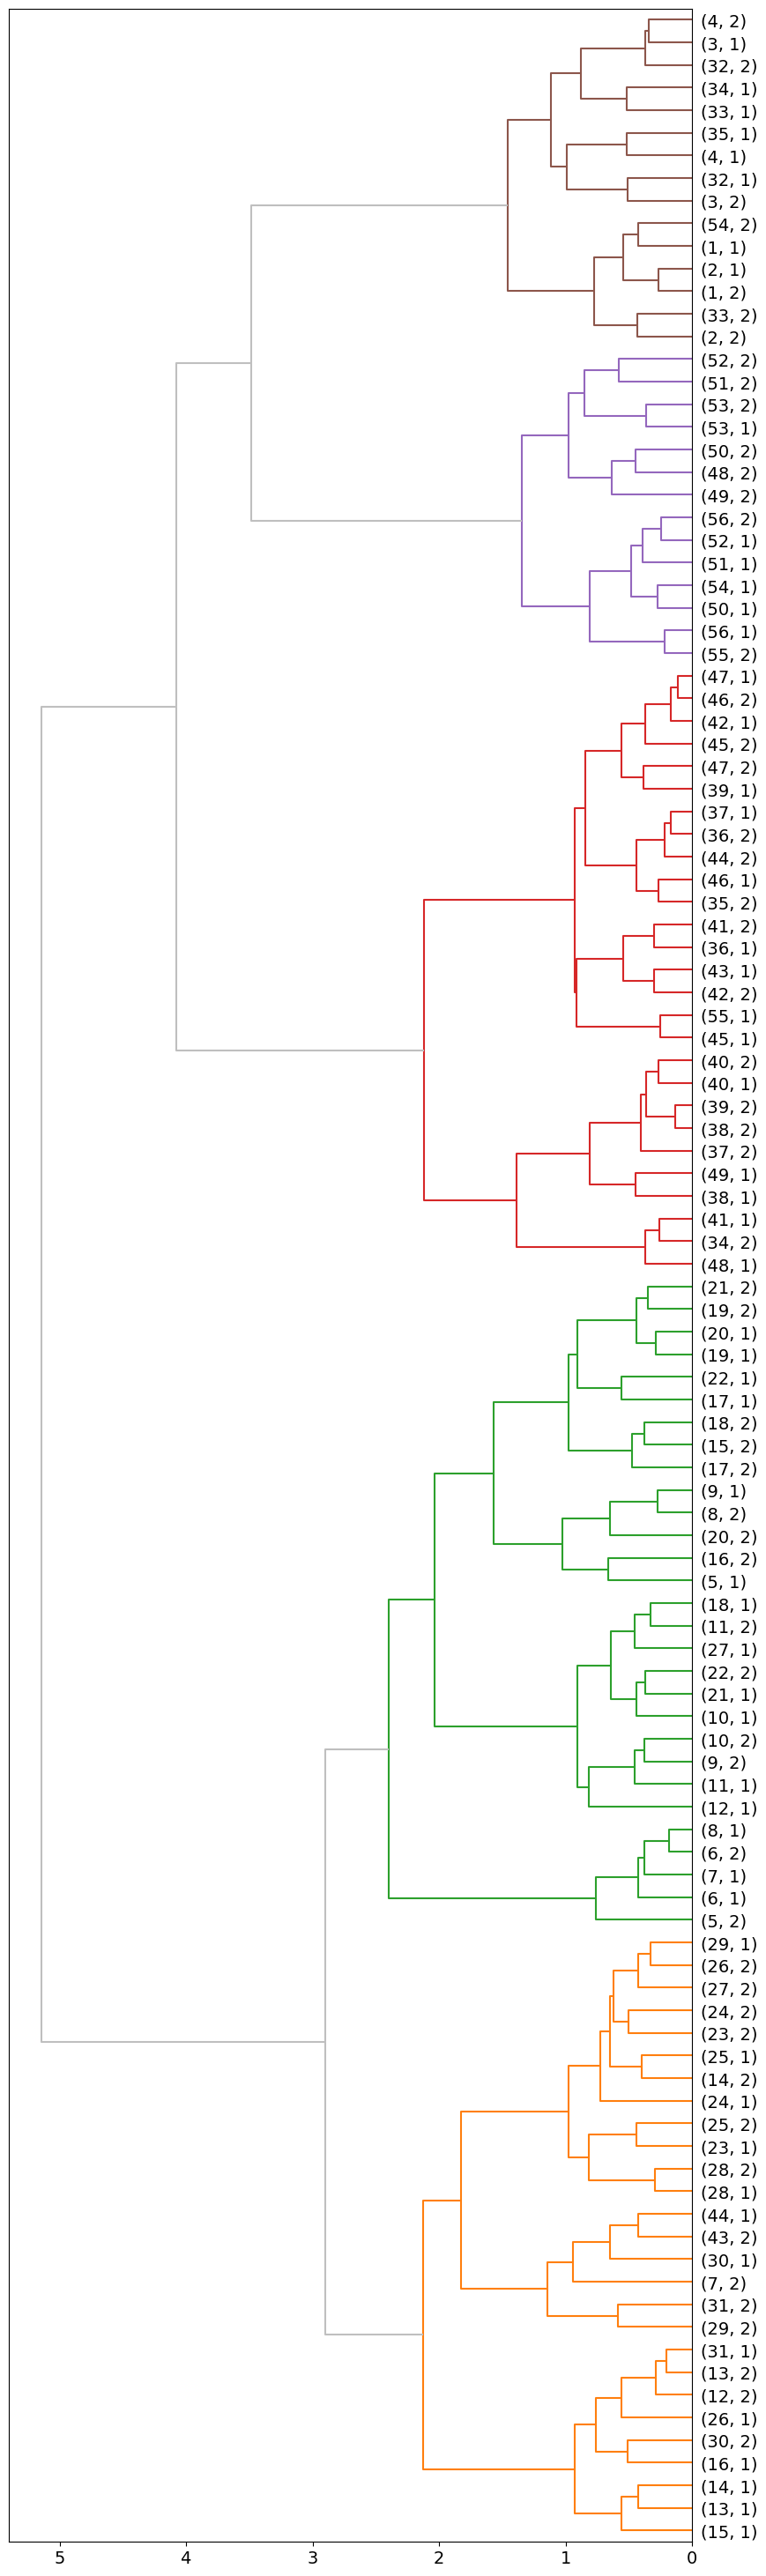

In [606]:
fig1.plot()

In [607]:
color_map = {
    "1": "lightcoral",        # Soft red
    "2": "lightskyblue",      # Light blue
    "3": "mediumorchid",      # Purple
    "4": "gold",              # Yellow-orange
    "5": "mediumseagreen",    # Green
    "6": "peachpuff",         # Soft peach
    "7": "dodgerblue",        # Vibrant blue
    "8": "darkkhaki",         # Muted yellow
    "9": "salmon",            # Warm pinkish-orange
    "10": "turquoise",        # Cyan-blue
    "11": "plum",             # Pastel purple
    "12": "chartreuse",       # Bright green-yellow
    "13": "mistyrose",        # Pale pink
    "14": "slateblue",        # Rich blue-violet
    "15": "orangered",        # Bright orange-red
    "16": "darkcyan",         # Deep cyan
    "17": "palegreen",        # Soft green
    "18": "lightgoldenrodyellow",  # Gentle yellow
    "19": "deepskyblue",      # Vibrant blue
    "20": "firebrick",        # Dark red
    "21": "mediumvioletred",  # Strong pink-purple
    "22": "lawngreen",        # Neon green
    "23": "royalblue",        # Rich blue
    "24": "sandybrown",        # Warm earthy tone
    "": 'white'
}

In [608]:
fig1.get_cluster_labels()
SRC['label'] = fig1.CLUSTER_LABELS.astype(str)
SRC.label.unstack(fill_value='')\
    .style.map(lambda x: 'background:' + color_map[x])

side,1,2
folio,,
1,5,5
2,5,5
3,5,5
4,5,5
5,2,2
6,2,2
7,2,1
8,2,2
9,2,2


In [610]:
SIDE.loc[(7,1)].side_str_norm

'quix huzuc xtzac vloc xmeho vloc tzam vteleb ta xutzocopih chi cut hunhunahpu ri vvcub caquix xavi vtz xquibano ma nabe quicha catahic tah rumal vvcub caquix vcaam chi cut veab ri hunhunahpu rumal ri vucub caquix ta xbe chi rochoch xa chi cu vlotem vqaqate xoponic naqui pa mi xcamou chila xqha cu ri chimalmat ri xoquil vvcub caquix na qui pa ri ri e caib qaxtoq mixiquivubah mi xzilibatah nu qaqate rumal xacachuiu ahe ve cacoxou chic minabe mixnucam vloc chuvi qaq cut chixeque vi chitzaiaba chuvi qaq ta cul qui cama chic quitzih chi e qaxtoq xqha ri vvcub caquix ta xu xequeba veab ri hunahpu qui naohinic chic ri huhun ahpu xbalanq’ ta xquibih cut chirech hun mama quitzih zac chic rizmal vi chi mama hun cu atit quitzih quemel atit chic xa quelucuquila chic chirihitac vinac zaqui nim ac vbi mama zaqui nima tziz cut vbi atit xeqha curi qaholab chique ri atit mama quixcachbilahtah chibe ta cama caeab ruq vucub caquix xa cohtere chivih quiri ca mam ri cachbilan caminac qui chuch qui cahau q

English Translation:

“And then the sky collapsed,
the earth was overturned,
the mountains trembled,
and Hun Hunahpu was defeated by Wuqub’ Caquix.

But his fate was already sealed,
for it was not by his own strength that he fell,
but by the will of Wuqub’ Caquix.

Hun Hunahpu was tricked and lured into the house of Wuqub’ Caquix.
There, he was taken captive,
bound in chains of silver and ropes of jade.
He was struck down,
and his blood was spilled upon the ground.

His severed head was placed within the branches of a great tree,
from which no fruit had ever grown.
But when his head was set upon the tree,
it began to bear fruit in abundance.

And so, his spirit did not perish.
Though he had been slain,
his wisdom remained within the world.

From that place, he spoke to his sons,
the twins Hunahpu and Xbalanq’e,
and they heard his words,
for his spirit was alive within them.

They understood his fate,
they knew that they would face the same trials.
And so, they prepared themselves,
for they were destined to restore balance to the world.

Thus, the fate of the great lords was sealed.
Their lineage would endure,
their names would be remembered.

For Hun Hunahpu and Wuqub’ Caquix had played their part,
and the world had been set in order.”

⸻

Context and Interpretation

This passage appears to recount the battle between Hun Hunahpu and Wuqub’ Caquix, an episode in the Popol Wuj that highlights the struggle between the mortal and the divine.
	•	Hun Hunahpu is tricked and killed by Wuqub’ Caquix, but his death is not the end.
	•	His head is placed in a tree, which then begins to bear miraculous fruit, symbolizing rebirth and transformation.
	•	Despite his death, his wisdom endures, and his sons, Hunahpu and Xbalanq’e, receive his knowledge, preparing for their own trials against Xibalba.

This passage reflects themes of sacrifice and resurrection, common in Mesoamerican mythology. The idea that wisdom and spirit live on beyond death is central to the Popol Wuj, reinforcing the concept of divine destiny and the cyclical nature of life.